## K-Means Clustering

### Assignment 1 (2 scores):

- Generate a toy dataset having $600$ data points: $200$ from $\mathcal{N}((2, 2), \Sigma)$, $200$ from $\mathcal{N}((8, 3), \Sigma)$, and $200$ from $\mathcal{N}((3, 6), \Sigma)$, where

$$\Sigma = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$$

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of intializing centroids randomly to the overall performance of K-means.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class KMeans: 
    def __init__(self, K=3, n_iters=100): 
        self.K = K 
        self.n_iters = n_iters 
        self.centroids = None 
        self.labels = None 

    def fit(self, X): 
        N = X.shape[0] 
        idx = np.random.choice(N, self.K, replace=False) 
        self.centroids = X[idx].copy() 

        for _ in tqdm(range(self.n_iters), desc='K-Means'): 
            dists = np.linalg.norm(X[:, None] - self.centroids[None], axis=2) 
            self.labels = np.argmin(dists, axis=1) 
            new_centroids = np.array([ 
                X[self.labels == k].mean(axis=0) if np.any(self.labels == k) else self.centroids[k] 
                for k in range(self.K) 
            ]) 
            if np.allclose(self.centroids, new_centroids): 
                break 
            self.centroids = new_centroids 
        return self 

    def predict(self, X): 
        dists = np.linalg.norm(X[:, None] - self.centroids[None], axis=2) 
        return np.argmin(dists, axis=1) 

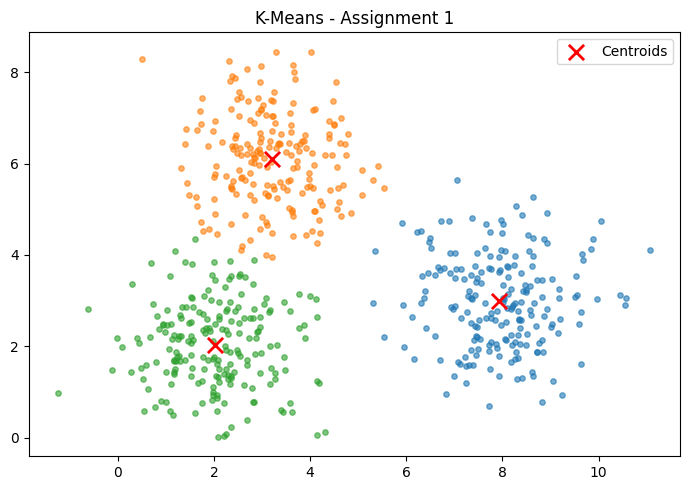

In [3]:
np.random.seed(42) 
sigma = np.eye(2) 

X1 = np.random.multivariate_normal([2, 2], sigma, 200) 
X2 = np.random.multivariate_normal([8, 3], sigma, 200) 
X3 = np.random.multivariate_normal([3, 6], sigma, 200) 
X = np.vstack([X1, X2, X3]) 

km1 = KMeans(K=3, n_iters=100) 
km1.fit(X) 

colors = ['tab:blue', 'tab:orange', 'tab:green'] 
plt.figure(figsize=(7, 5)) 
for k in range(3): 
    mask = km1.labels == k 
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=15, alpha=0.6) 
plt.scatter(km1.centroids[:, 0], km1.centroids[:, 1], 
            c='red', marker='x', s=120, linewidths=2, label='Centroids') 
plt.title('K-Means - Assignment 1') 
plt.legend() 
plt.tight_layout() 
plt.show() 

Since centroids are randomly initialized, running K-means twice can produce different clusterings. A bad draw may place two initial centroids inside the same true cluster while leaving another uncovered. For this case with well-separated, equal-size clusters the algorithm usually converges correctly, but label assignments may vary across runs. Running K-means multiple times and keeping the result with the lowest $J$ reduces this sensitivity.

### Assignment 2 (2 scores):

- Generate a toy dataset having $1200$ points from $\mathcal{N}((2, 2), \Sigma)$, $200$ points from $\mathcal{N}((8, 3), \Sigma)$, and $1000$ points from $\mathcal{N}((3, 6), \Sigma)$, where

$$\Sigma = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$$

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of different sizes among clusters to the performance of K-means.

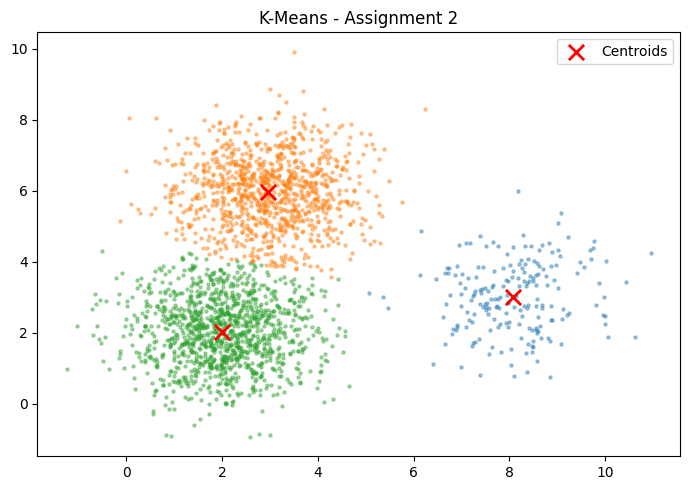

In [4]:
np.random.seed(42) 

X1b = np.random.multivariate_normal([2, 2], np.eye(2), 1200) 
X2b = np.random.multivariate_normal([8, 3], np.eye(2), 200) 
X3b = np.random.multivariate_normal([3, 6], np.eye(2), 1000) 
Xb = np.vstack([X1b, X2b, X3b]) 

km2 = KMeans(K=3, n_iters=100) 
km2.fit(Xb) 

plt.figure(figsize=(7, 5)) 
for k in range(3): 
    mask = km2.labels == k 
    plt.scatter(Xb[mask, 0], Xb[mask, 1], c=colors[k], s=5, alpha=0.4) 
plt.scatter(km2.centroids[:, 0], km2.centroids[:, 1], 
            c='red', marker='x', s=120, linewidths=2, label='Centroids') 
plt.title('K-Means - Assignment 2') 
plt.legend() 
plt.tight_layout() 
plt.show() 

K-means minimizes total squared distance, so larger clusters contribute more to $J$ and pull centroids more strongly toward their regions. The small cluster (200 points around $(8, 3)$) is spatially separated enough that it is usually recovered correctly. The boundary between the two large overlapping clusters (1200 and 1000 points) is less stable and can shift depending on the initial centroid positions, occasionally causing one centroid to drift into the overlap region.

### Assignment 3 (2 scores):

- Generate a toy dataset having $600$ data points: $200$ from $\mathcal{N}((2, 2), \Sigma_1)$, $200$ from $\mathcal{N}((8, 3), \Sigma_1)$, and $200$ from $\mathcal{N}((3, 6), \Sigma_2)$, where

$$\Sigma_1 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}, \quad \Sigma_2 = \begin{pmatrix} 10 & 0 \\ 0 & 1 \end{pmatrix}$$

- Use Numpy only to implement the K-means method for finding three clusters from the toy dataset.
- Train this K-means with EM method.
- Give comments on the effect of distribution $\mathcal{N}((3, 6), \Sigma_2)$ to the performance of K-means.

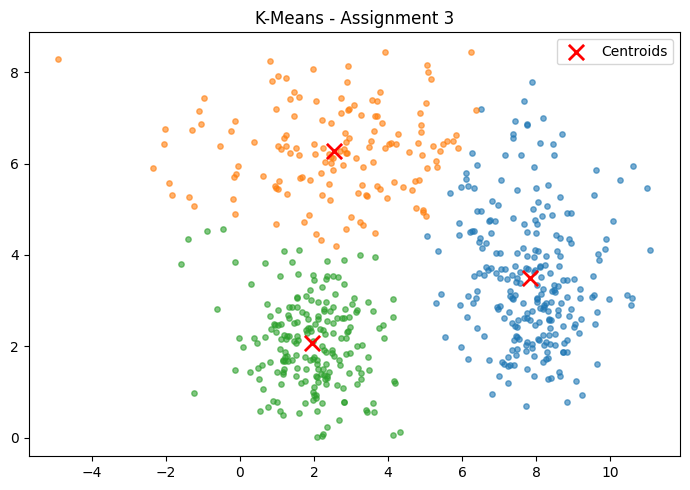

In [5]:
np.random.seed(42) 
sigma1 = np.eye(2) 
sigma2 = np.array([[10, 0], [0, 1]], dtype=float) 

X1c = np.random.multivariate_normal([2, 2], sigma1, 200) 
X2c = np.random.multivariate_normal([8, 3], sigma1, 200) 
X3c = np.random.multivariate_normal([3, 6], sigma2, 200) 
Xc = np.vstack([X1c, X2c, X3c]) 

km3 = KMeans(K=3, n_iters=100) 
km3.fit(Xc) 

plt.figure(figsize=(7, 5)) 
for k in range(3): 
    mask = km3.labels == k 
    plt.scatter(Xc[mask, 0], Xc[mask, 1], c=colors[k], s=15, alpha=0.6) 
plt.scatter(km3.centroids[:, 0], km3.centroids[:, 1], 
            c='red', marker='x', s=120, linewidths=2, label='Centroids') 
plt.title('K-Means - Assignment 3') 
plt.legend() 
plt.tight_layout() 
plt.show() 

K-means uses Euclidean distance and implicitly assumes spherical clusters. The third cluster with $\Sigma_2 = \text{diag}(10, 1)$ is much wider along the x-axis, so points scatter far from the centroid in that direction. K-means places the centroid near the geometric center but misassigns points at the edges to whichever neighboring centroid is closest. GMM with full covariance explicitly learns the cluster shape and handles this case better.